In [1]:
import os
import sys

import numpy

# Add OpenBLAS bin to the beginning of the PATH
os.environ["PATH"] = r"C:\TopoGAN-ECCV2020\OpenBLAS\bin;" + os.environ.get("PATH", "")

# # 1) register the folder that contains _persis_homo_optimal.pyd *and* any other DLLs it needs
# os.add_dll_directory(r"C:\Users\MIKEC\PycharmProjects\topology\TopoGAN-ECCV2020\persis_lib_cpp")

# 2) add the same folder to sys.path so Python can find the .pyd module by name
# sys.path.insert(0, r"C:\Users\MIKEC\PycharmProjects\topology\TopoGAN-ECCV2020\persis_lib_cpp")

# python library compile from cpp
sys.path.insert(0, "./persis_lib_cpp")
import os

from persis_homo_optimal import *

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # Добавьте это в первой ячейке
TOPOLOGICAL_GAN = True
START_TOPO_LOSS_FROM_EPOCH = -1

%run Archpool.ipynb
%run Argparser.ipynb
%run GAN.ipynb


def precompute_pds(dir_in, dir_out):
    adv_params = return_advanced_params()
    et = Edges_(adv_params, False)
    FileIO.compute_pd_save(dir_in, dir_out, "png", adv_params, 1, True)


settings = return_settings()

raw_data_path, pds_path = settings["Path"]["data_path"], settings["Path"]["pds_path"]
if not os.path.exists(pds_path):
    print("Precomputing pds")  # PDs - Persistence Diagrams

    print(raw_data_path, "\n", pds_path)
    precompute_pds(raw_data_path, pds_path)

In [2]:
parser = Argparser(settings)
general = return_general(0)
G_arch = return_arch(2)
D_arch = return_arch(3)
data_params = return_data_settings(0)
adv_params = return_advanced_params()

print("TRAINING ON DATASET: ", settings["Path"]["data_path"])

TRAINING ON DATASET:  C:\TopoGAN-ECCV2020\Data\rock\64x64small++


In [3]:
import json
import os
from datetime import datetime
from pathlib import Path

# Get the filename: YYYY-MM-DD_branchname.json
date_str = datetime.now().strftime("%Y-%m-%d")
branch_name = settings["Basic"]["branch_name"]
filename = f"{date_str}_{branch_name}.json"

# Full save path
save_dir = Path(settings["Path"]["save_path"]) / branch_name
os.makedirs(save_dir, exist_ok=True)
save_file_path = os.path.join(save_dir, filename)

# Assemble the full run config
run_config = {
    #     "args": vars(parser),
    "settings": settings,
    "general": general,
    "generator_arch": G_arch,
    "discriminator_arch": D_arch,
    "data_params": data_params,
    "advanced_params": adv_params,
}

# Save to JSON
with open(save_file_path, "w") as f:
    json.dump(run_config, f, indent=4)

print(f"✅ Run configuration saved to: {save_file_path}")

✅ Run configuration saved to: C:\TopoGAN-ECCV2020\Data\LOG\rock_20250525_160826_64x64small++\2025-05-25_rock_20250525_160826_64x64small++.json


In [4]:
def compute_fid(paths, batch_size=50, dims=2048):
    """
    reference: https://github.com/mseitzer/pytorch-fid
    dims choices: 64, 192, 768, 2048
    lower score means better quality
    paths: [folderA, folderB]
    """
    %run fid/inception.ipynb
    %run fid/fid_score.ipynb

    os.environ["CUDA_VISIBLE_DEVICES"] = "0"
    fid_value = calculate_fid_given_paths(paths, batch_size, True, dims)
    print("FID: ", fid_value)


def run(gan):
    gan.train(
        data_params,
        withTopo=TOPOLOGICAL_GAN,
        add_topo_at_epoch=START_TOPO_LOSS_FROM_EPOCH,
    )
    # gan.sample_save_("20000_128_1_1_0.dat", [20000, 128, 1, 1], "D:/Data/isbi/2w/compare_SN0", 127.5, 0)
    # gan.save_noise_([20000, 128, 1, 1], "20000_128_1_1_2.dat")


#     print("Precomputing pds") # PDs - Persistence Diagrams
#     precompute_pds(r"C:\TopoGAN-ECCV2020\Data\cremi\64x64", r"C:\TopoGAN-ECCV2020\Data\cremi\pds_64x64")

def train():
    gan = GAN(general, adv_params, G_arch, D_arch)
    start_time = time.time()
    try:
        print(
            "TOPOLOGICAL_GAN:",
            TOPOLOGICAL_GAN,
            "starting from epoch",
            START_TOPO_LOSS_FROM_EPOCH,
        )
        run(gan)
    finally:
        end_time = time.time()
        elapsed_time = end_time - start_time
        hours, rem = divmod(elapsed_time, 3600)
        minutes, seconds = divmod(rem, 60)
        print(f"Execution time: {int(hours):02d}:{int(minutes):02d}:{seconds:06.3f}")
        #     precompute_pds('E:/Data/cremi', 'E:/Data/cremi/pds')
        # compute_fid(["D:/Data/facades/facade128", "D:/Data/facades/match0.0005"])
        # gan.plot_losses(date_str, save_file_path, logscale={"d": True, "g": True, "t": True, "w": True})
        # gan.plot_losses(date_str, save_file_path, logscale={"g": True, "d": True})
        gan.plot_losses(date_str, save_file_path)
        
# train()

In [5]:
1

1

In [6]:
import matplotlib.pyplot as plt
import numpy as np


def plot_persistence_diagram(
    mat, title="Persistence Diagram", show=True, save_path=None
):
    """
    Plot a persistence diagram given a matrix of birth-death pairs.

    Parameters:
        mat (np.ndarray): Array of shape (N, 2), where each row is (birth, death)
        title (str): Plot title
        show (bool): Whether to display the plot
        save_path (str or None): If given, saves the plot to this path
    """
    if mat.ndim != 2 or mat.shape[1] != 2:
        raise ValueError(
            "mat must be a 2D array with shape (N, 2), representing (birth, death) pairs."
        )

    births, deaths = mat[:, 0], mat[:, 1]

    plt.figure(figsize=(6, 6))
    plt.scatter(births, deaths, c="blue", alpha=0.6, edgecolors="k")
    max_val = max(np.max(births), np.max(deaths)) * 1.05
    plt.plot([0, max_val], [0, max_val], "r--", label="Diagonal (birth=death)")
    plt.xlabel("Birth")
    plt.ylabel("Death")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.axis("equal")

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close()


def plot_persistence_diagram_from_file(
    file_path, title="Persistence Diagram", show=True, save_path=None
):
    def read_matrix_binary(path, dtype="d"):
        file_in = open(path, "rb")
        dims = struct.unpack("I", file_in.read(4))[0]
        if dims == 0:
            return None
        shape = struct.unpack(str(dims) + "I", file_in.read(4 * dims))
        mat = struct.unpack(
            str(np.prod(shape)) + dtype,
            file_in.read(dlength_dict[dtype] * np.prod(shape)),
        )
        mat = np.reshape(mat, shape)
        return mat

    pd_matrix = read_matrix_binary(file_path)
    return plot_persistence_diagram(pd_matrix, title, show, save_path)

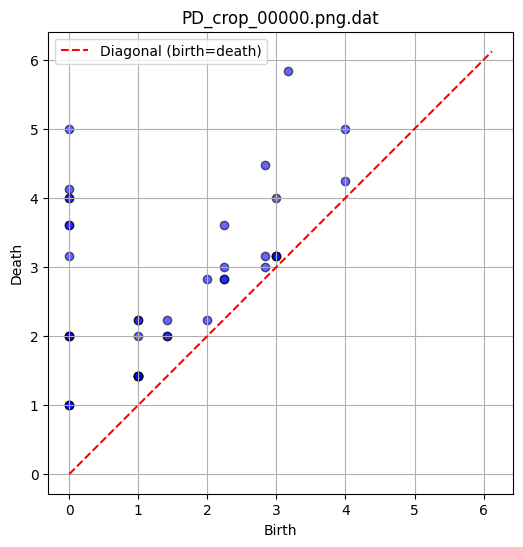

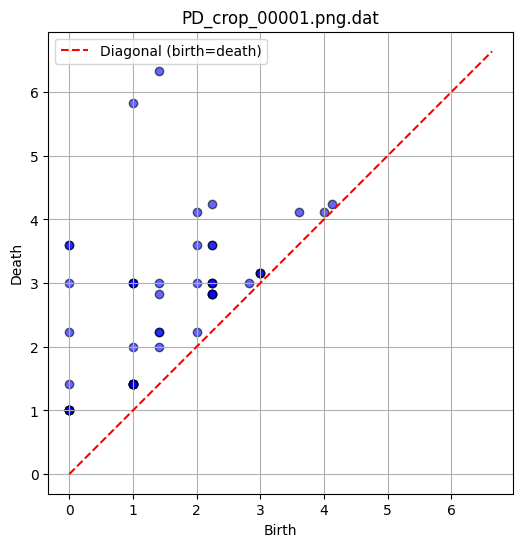

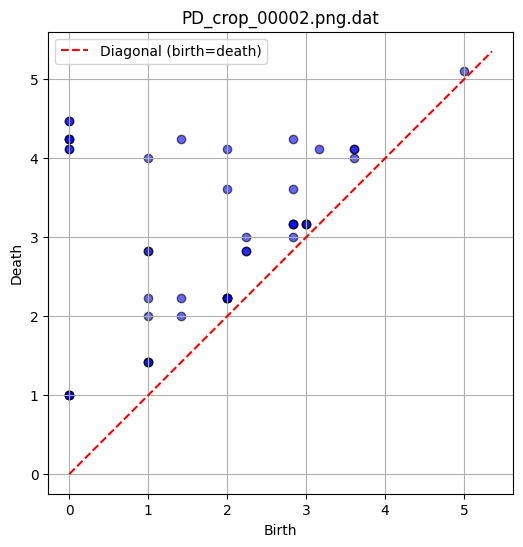

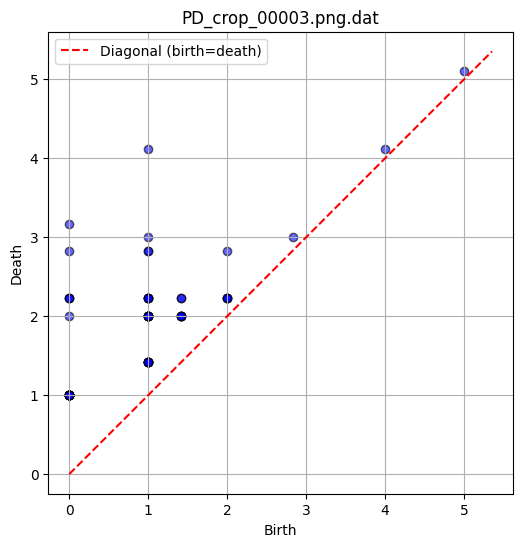

In [7]:
from pathlib import Path

pds_path = Path("C:\TopoGAN-ECCV2020\Data\cremi\pds_64x64_downscaled_from_256")
pd_names = [
    "crop_00000.png.dat",
    "crop_00001.png.dat",
    "crop_00002.png.dat",
    "crop_00003.png.dat",
]

for name in pd_names:
    path = pds_path / name
    plot_persistence_diagram_from_file(path, title="PD_" + name)

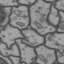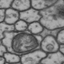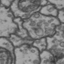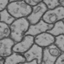

In [8]:
%cd C:\TopoGAN-ECCV2020

C:\TopoGAN-ECCV2020


In [9]:
%run inference.ipynb

In [10]:
rom pathlib import Path
from datetime import datetime

experiment_name = "release_test_20250517_214006_64x64"
weights_path = Path(f"C:/TopoGAN-ECCV2020/Data/LOG/{experiment_name}/models")
generations_path = Path(f"C:/TopoGAN-ECCV2020/Data/generations/cremi/{experiment_name}")
step = 2000

# Get current datetime and format it as a string
current_time = datetime.now().strftime("%Y.%m.%d_%H.%M.%S")

# Add datetime to the end of the generations_path stem
generations_path = generations_path.with_stem(f"{generations_path.stem}_{current_time}")

In [ ]:
gan_kwargs = {
    "general": general,
    "adv_params": adv_params,
    "G_arch": G_arch,
    "D_arch": D_arch,
}
generate_images(GAN, weights_path, generations_path, gan_kwargs=gan_kwargs, step=step, num_samples=1000, fix_with_topo=False)

In [ ]:
compute_fid([path1, path2])